# CH04_예측

---
## 4.1 선거 결과 예측하기
---

### 4.1.1: Loops in Python

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import os

os.chdir('/home/user/repo/studies/qss/data')

In [77]:
values = np.array([2,4,6])
n = len(values)
results = np.zeros(n)

for i in range(n):
    results[i] = values[i] * 2
    print(f"{values[i]} times 2 is equal to {results[i]}")

results

2 times 2 is equal to 4.0
4 times 2 is equal to 8.0
6 times 2 is equal to 12.0


array([ 4.,  8., 12.])

In [78]:
i = 0
x = values[i] * 2
print(f"{values[i]} times 2 is equal to {x}")

2 times 2 is equal to 4


In [79]:
values * 2

array([ 4,  8, 12])

### 4.1.2: General Conditional Statements in Python

In [80]:
operation = 'add'

if operation == 'add':
    print('I will perform addition 4 + 4')
    print(4 + 4)

if operation == 'multiply':
    print('I will perform multiplication 4 * 4')
    print(4 * 4)

I will perform addition 4 + 4
8


In [81]:
operation = 'multiply'

if operation == 'add':
    print('I will perform addition 4 + 4')
    print(4 + 4)
else:
    print('I will perform multiplication 4 * 4')
    print(4 * 4)

I will perform multiplication 4 * 4
16


In [82]:
operation = 'subtract'

if operation == 'add':
    print('I will perform addition 4 + 4')
    print(4 + 4)
elif operation == 'multiply':
    print('I will perform multiplication 4 * 4')
    print(4 * 4)
else:
    print(f"'{operation}' is invalid. Use either 'add' or 'multiply'")

'subtract' is invalid. Use either 'add' or 'multiply'


In [83]:
values = np.arange(1,6)
n = len(values)
results = np.zeros(n)

for i in range(n):
    x = values[i]
    r = x % 2
    if r == 0:
        print(f"{x} is even and I will perform addition {x} + {x}")
        results[i] = x + x
    else:
        print(f"{x} is add and I will perform multiplication {x} * {x}")
        results[i] = x * x

results


1 is add and I will perform multiplication 1 * 1
2 is even and I will perform addition 2 + 2
3 is add and I will perform multiplication 3 * 3
4 is even and I will perform addition 4 + 4
5 is add and I will perform multiplication 5 * 5


array([ 1.,  4.,  9.,  8., 25.])

### 4.1.3 여론조사 결과 예측

In [84]:
from datetime import datetime

In [85]:
pres08 = pd.read_csv('pres08.csv')
polls08 = pd.read_csv('polls08.csv')

In [86]:
polls08['margin'] = polls08.Obama - polls08.McCain
pres08['margin'] = pres08.Obama - pres08.McCain

In [87]:
pres08.head()

,state.name,state,Obama,McCain,EV,margin
0,Alabama,AL,39,60,9,-21
1,Alaska,AK,38,59,3,-21
2,Arizona,AZ,45,54,10,-9
3,Arkansas,AR,39,59,6,-20
4,California,CA,61,37,55,24


In [88]:
polls08.head()

,state,Pollster,Obama,McCain,middate,margin
0,AL,SurveyUSA-2,36,61,2008-10-27,-25
1,AL,Capital Survey-2,34,54,2008-10-15,-20
2,AL,SurveyUSA-2,35,62,2008-10-08,-27
3,AL,Capital Survey-2,35,55,2008-10-06,-20
4,AL,Rasmussen-1,39,60,2008-09-22,-21


In [89]:
x = datetime.strptime('2008-11-04', '%Y-%m-%d')
y = datetime.strptime('2008/9/1', '%Y/%m/%d')

x-y

datetime.timedelta(days=64)

In [90]:
(x-y).days

64

In [91]:
polls08['middate'] = pd.to_datetime(polls08['middate'])
polls08['days_to_election'] = (x - polls08['middate']).dt.days

In [92]:
st_names = polls08['state'].unique()
st_names

<StringArray>
['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'ID',
 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO',
 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA',
 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY']
Length: 51, dtype: str

In [93]:
poll_pred = pd.Series(index=st_names)
poll_pred.head()

AL   NaN
AK   NaN
AZ   NaN
AR   NaN
CA   NaN
dtype: float64

In [94]:
for i in range(len(st_names)):
    state_data = polls08[polls08['state'] == st_names[i]]
    latest = (state_data[state_data['days_to_election'] == state_data['days_to_election'].min()])
    poll_pred.iloc[i] = latest['margin'].mean()

In [95]:
poll_pred.head(10)

AL   -25.0
AK   -19.0
AZ    -2.5
AR    -7.0
CA    24.0
CO     7.0
CT    25.0
DC    69.0
DE    30.0
FL     2.0
dtype: float64

In [96]:
poll_pred_alt = pd.Series(index=st_names)

for state in st_names:
    state_data = polls08[polls08['state'] == state]
    latest = (state_data[state_data['days_to_election'] == 
                         state_data['days_to_election'].min()])
    poll_pred_alt[state] = latest['margin'].mean()

poll_pred.equals(poll_pred_alt)

True

In [97]:
errors = pres08.set_index('state')['margin'] - poll_pred
errors.head()

state
AL     4.0
AK    -2.0
AZ    -6.5
AR   -13.0
CA     0.0
dtype: float64

In [98]:
errors.mean()

np.float64(1.0620915032679739)

In [99]:
np.sqrt((errors**2).mean())

np.float64(5.908940458495747)

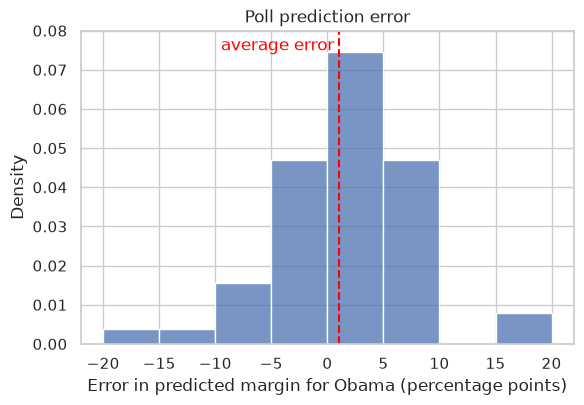

In [100]:
sns.set_theme(style="whitegrid")

sns.displot(
    x=errors, stat='density', binrange=(-20,20), binwidth=5,
    height=4, aspect=1.5,
).set(xlabel='Error in predicted margin for Obama (percentage points)',
      title='Poll prediction error',
      ylim=(0, 0.08)).despine(right=False, top=False)

plt.axvline(x=errors.mean(), color='red', linestyle='--')
plt.text(x=-9.5, y=0.075, s='average error', color='red');

In [101]:
pres08['poll_pred'] = poll_pred.reset_index(drop=True)

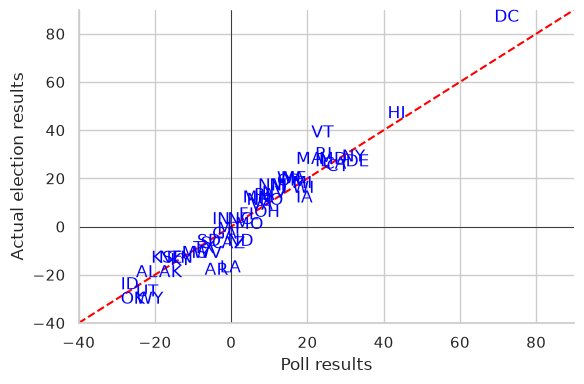

In [102]:
sns.relplot(
    data=pres08, x='poll_pred', y='margin', marker='',
    height=4, aspect=1.5,
).set(xlabel='Poll results', ylabel='Actual election results',
      ylim=(-40,90), xlim=(-40,90))

for i in range(len(pres08['state'])):
    plt.text(x=pres08['poll_pred'][i], y=pres08['margin'][i],
             s=pres08['state'][i], color='blue')

plt.gca().axline((0,0), slope=1, color='red', linestyle='--')

plt.axvline(x=0, color='black', linewidth=0.5)
plt.axhline(y=0, color='black', linewidth=0.5);

In [103]:
pres08['state'][np.sign(pres08['poll_pred']) != np.sign(pres08['margin'])]

14    IN
25    MO
33    NC
Name: state, dtype: str

In [104]:
pres08['margin'][np.sign(pres08['poll_pred']) != np.sign(pres08['margin'])]

14    1
25   -1
33    1
Name: margin, dtype: int64

In [105]:
pres08['EV'][pres08['margin'] > 0].sum()

np.int64(364)

In [106]:
pres08['EV'][pres08['poll_pred'] > 0].sum()

np.int64(349)

In [107]:
pollsUS08 = pd.read_csv('pollsUS08.csv', parse_dates=['middate'])
pollsUS08['days_to_election'] = (x - pollsUS08['middate']).dt.days

In [108]:
Obama_pred = np.zeros(90)
McCain_pred = np.zeros(90)

In [109]:
for i in range(len(Obama_pred)):
    week_data = (pollsUS08[(pollsUS08['days_to_election'] <= (90 - (i + 1) + 7))
                           & (pollsUS08['days_to_election'] > (90 - (i + 1)))])
    Obama_pred[i] = week_data['Obama'].mean()
    McCain_pred[i] = week_data['McCain'].mean()

pollsUS08_avg = pd.DataFrame({
    'Obama': Obama_pred,
    'McCain': McCain_pred,
    'days_to_election': np.arange(90, 0, -1)
})

pollsUS08_avg.head()

,Obama,McCain,days_to_election
0,44.538462,40.692308,90
1,45.000000,40.692308,89
2,45.230769,40.846154,88
3,45.750000,42.000000,87
4,45.888889,42.000000,86


In [110]:
pollsUS08_avg_long = pollsUS08_avg.melt(id_vars='days_to_election',
                                        var_name='Candidate',
                                        value_name='poll_avg')

pollsUS08_avg_long

,days_to_election,Candidate,poll_avg
0,90,Obama,44.538462
1,89,Obama,45.000000
2,88,Obama,45.230769
3,87,Obama,45.750000
4,86,Obama,45.888889
...,...,...,...
175,5,McCain,43.384615
176,4,McCain,43.708333
177,3,McCain,44.000000
178,2,McCain,44.185185


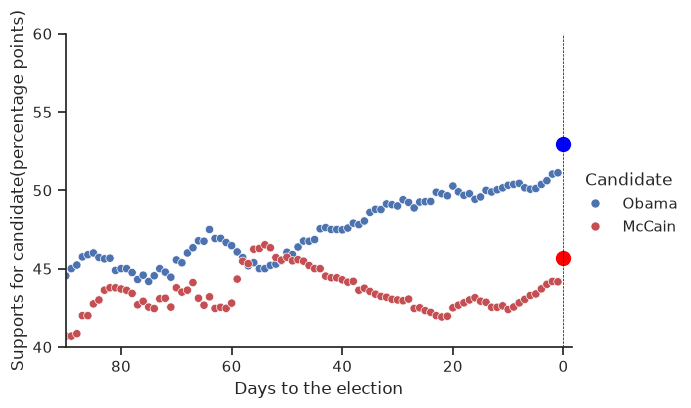

In [111]:
sns.set_theme(style='ticks')

sns.relplot(
    data=pollsUS08_avg_long, x='days_to_election', y='poll_avg',
    hue='Candidate', kind='scatter', # kind='line'
    palette=['b', 'r'], height=4, aspect=1.5
).set(
    ylim=(40, 60), yticks=range(40, 61, 5),
    xlim=(90, -1.5),
    xlabel='Days to the election',
    ylabel='Supports for candidate(percentage points)'
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=.5)

plt.scatter(0, 52.93, color='blue', s=100)
plt.scatter(0, 45.65, color='red', s=100);

---
## 4.2 선형회귀
---

### 4.2.1 얼굴 생김새와 선거 결과

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import os

os.chdir('/home/user/repo/studies/qss/data')

In [113]:
face = pd.read_csv('face.csv')
face.head()

,year,state,winner,loser,w.party,l.party,d.comp,r.comp,d.votes,r.votes
0,2000,CA,Feinstein,Campbell,D,R,0.564568,0.435432,5790154,3779325
1,2000,DE,Carper,Roth,D,R,0.341912,0.658088,181387,142683
2,2000,FL,Nelson,McCollum,D,R,0.612368,0.387632,2987644,2703608
3,2000,GA,Miller,Mattingly,D,R,0.541533,0.458467,1390428,933698
4,2000,HI,Akaka,Carroll,D,R,0.680232,0.319768,251130,84657


In [114]:
face['d_share'] = face['d.votes'] / (face['d.votes'] + face['r.votes'])
face['r_share'] = face['r.votes'] / (face['d.votes'] + face['r.votes'])
face['diff_share'] = face['d_share'] - face['r_share']

In [115]:
face.head()

,year,state,winner,loser,w.party,l.party,d.comp,r.comp,d.votes,r.votes,d_share,r_share,diff_share
0,2000,CA,Feinstein,Campbell,D,R,0.564568,0.435432,5790154,3779325,0.605065,0.394935,0.210129
1,2000,DE,Carper,Roth,D,R,0.341912,0.658088,181387,142683,0.559715,0.440285,0.119431
2,2000,FL,Nelson,McCollum,D,R,0.612368,0.387632,2987644,2703608,0.524954,0.475046,0.049907
3,2000,GA,Miller,Mattingly,D,R,0.541533,0.458467,1390428,933698,0.598258,0.401742,0.196517
4,2000,HI,Akaka,Carroll,D,R,0.680232,0.319768,251130,84657,0.747885,0.252115,0.495770


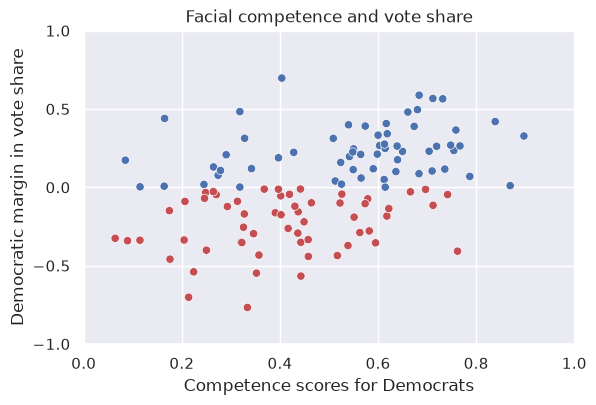

In [116]:
sns.relplot(
    data=face, x='d.comp', y='diff_share',
    hue='w.party', palette=['b', 'r'], legend=False, height=4, aspect=1.5,
).set(xlim=(0,1), ylim=(-1,1), yticks=np.arange(-1.0, 1.5, 0.5),
      title='Facial competence and vote share',
      xlabel='Competence scores for Democrats',
      ylabel='Democratic margin in vote share');

### 4.2.2 상관관계와 산점도

In [117]:
face['d.comp'].corr(face['diff_share'])

np.float64(0.43277434572761064)

### 4.2.3 최소제곱

In [118]:
import statsmodels.formula.api as smf

In [119]:
face.columns

Index(['year', 'state', 'winner', 'loser', 'w.party', 'l.party', 'd.comp',
       'r.comp', 'd.votes', 'r.votes', 'd_share', 'r_share', 'diff_share'],
      dtype='str')

In [120]:
face.columns = face.columns.str.replace('.', '_')
face.columns

Index(['year', 'state', 'winner', 'loser', 'w_party', 'l_party', 'd_comp',
       'r_comp', 'd_votes', 'r_votes', 'd_share', 'r_share', 'diff_share'],
      dtype='str')

In [121]:
fit = smf.ols('diff_share ~ d_comp', data=face).fit()

In [122]:
fit.model.formula

'diff_share ~ d_comp'

In [123]:
fit.params

Intercept   -0.312226
d_comp       0.660381
dtype: float64

In [124]:
fit.fittedvalues.head(10)

0    0.060604
1   -0.086433
2    0.092171
3    0.045392
4    0.136987
5   -0.100572
6   -0.045593
7    0.085994
8    0.043438
9    0.261788
dtype: float64

In [125]:
intercept, slope = fit.params
intercept, slope

(-0.31222587527907464, 0.6603814567765847)

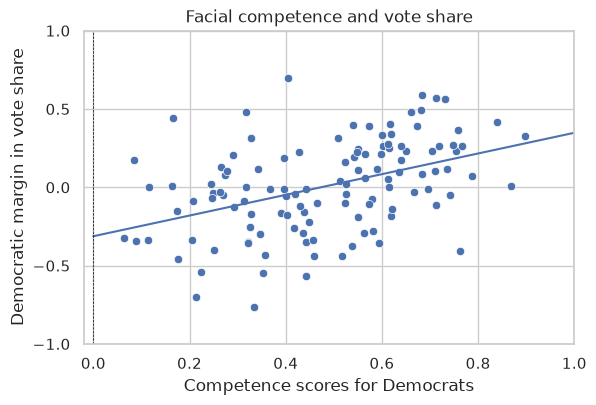

In [126]:
x_values = np.array([0,1])
y_values = intercept + slope * x_values

sns.set_theme(style='whitegrid')

sns.relplot(
    data=face, x='d_comp', y='diff_share', height=4, aspect=1.5
).set(ylim=(-1,1), yticks=np.arange(-1.0, 1.5, 0.5),
      xlim=(-0.02, 1),
      title='Facial competence and vote share',
      xlabel='Competence scores for Democrats',
      ylabel='Democratic margin in vote share').despine(right=False, top=False)

plt.plot(x_values, y_values)
plt.axvline(x=0, color='black', linewidth=.5, linestyle='--');

In [127]:
epsilon_hat = fit.resid
np.sqrt((epsilon_hat**2).mean())

np.float64(0.2642360764039512)

### 4.2.4 평균으로의 회귀

### 4.2.5: Merging Datasets in Pandas

In [128]:
pres12 = pd.read_csv('pres12.csv')
pres12.head()

,state,Obama,Romney,EV
0,AL,38,61,9
1,AK,41,55,3
2,AZ,45,54,11
3,AR,37,61,6
4,CA,60,37,55


In [130]:
pres08.drop('poll_pred', axis=1, inplace=True)
pres08.head()

,state.name,state,Obama,McCain,EV,margin
0,Alabama,AL,39,60,9,-21
1,Alaska,AK,38,59,3,-21
2,Arizona,AZ,45,54,10,-9
3,Arkansas,AR,39,59,6,-20
4,California,CA,61,37,55,24


In [131]:
pres = pd.merge(pres08, pres12, on='state')
pres.head()

,state.name,state,Obama_x,McCain,EV_x,margin,Obama_y,Romney,EV_y
0,Alabama,AL,39,60,9,-21,38,61,9
1,Alaska,AK,38,59,3,-21,41,55,3
2,Arizona,AZ,45,54,10,-9,45,54,11
3,Arkansas,AR,39,59,6,-20,37,61,6
4,California,CA,61,37,55,24,60,37,55


In [132]:
pres.describe().round(2)

,Obama_x,McCain,EV_x,margin,Obama_y,Romney,EV_y
count,51.00,51.00,51.00,51.00,51.00,51.00,51.00
mean,51.37,47.06,10.55,4.31,49.06,49.04,10.55
std,11.04,11.04,9.58,22.07,11.80,11.79,9.69
min,33.00,7.00,3.00,-32.00,25.00,7.00,3.00
25%,43.00,40.00,4.50,-13.00,40.50,41.00,4.50
50%,51.00,47.00,8.00,4.00,51.00,48.00,8.00
75%,57.50,56.00,11.50,17.50,56.00,58.00,11.50
max,92.00,66.00,55.00,85.00,91.00,73.00,55.00


In [133]:
pres12.rename(columns={'state':'state_abb'}, inplace=True)
pres12.head()

,state_abb,Obama,Romney,EV
0,AL,38,61,9
1,AK,41,55,3
2,AZ,45,54,11
3,AR,37,61,6
4,CA,60,37,55


In [134]:
pres = (pd.merge(pres08, pres12, left_on='state', right_on='state_abb').drop('state_abb', axis=1))
pres.head()

,state.name,state,Obama_x,McCain,EV_x,margin,Obama_y,Romney,EV_y
0,Alabama,AL,39,60,9,-21,38,61,9
1,Alaska,AK,38,59,3,-21,41,55,3
2,Arizona,AZ,45,54,10,-9,45,54,11
3,Arkansas,AR,39,59,6,-20,37,61,6
4,California,CA,61,37,55,24,60,37,55


In [135]:
pres.describe().round(2)

,Obama_x,McCain,EV_x,margin,Obama_y,Romney,EV_y
count,51.00,51.00,51.00,51.00,51.00,51.00,51.00
mean,51.37,47.06,10.55,4.31,49.06,49.04,10.55
std,11.04,11.04,9.58,22.07,11.80,11.79,9.69
min,33.00,7.00,3.00,-32.00,25.00,7.00,3.00
25%,43.00,40.00,4.50,-13.00,40.50,41.00,4.50
50%,51.00,47.00,8.00,4.00,51.00,48.00,8.00
75%,57.50,56.00,11.50,17.50,56.00,58.00,11.50
max,92.00,66.00,55.00,85.00,91.00,73.00,55.00


In [136]:
pres1 = pd.concat([pres08, pres12], axis='columns')
pres1.head()

,state.name,state,Obama,McCain,EV,margin,state_abb,Obama,Romney,EV
0,Alabama,AL,39,60,9,-21,AL,38,61,9
1,Alaska,AK,38,59,3,-21,AK,41,55,3
2,Arizona,AZ,45,54,10,-9,AZ,45,54,11
3,Arkansas,AR,39,59,6,-20,AR,37,61,6
4,California,CA,61,37,55,24,CA,60,37,55


In [137]:
pres1.iloc[7:9]

,state.name,state,Obama,McCain,EV,margin,state_abb,Obama,Romney,EV
7,D.C.,DC,92,7,3,85,DE,59,40,3
8,Delaware,DE,62,37,3,25,DC,91,7,3


In [138]:
pres.iloc[7:9]

,state.name,state,Obama_x,McCain,EV_x,margin,Obama_y,Romney,EV_y
7,D.C.,DC,92,7,3,85,91,7,3
8,Delaware,DE,62,37,3,25,59,40,3


In [139]:
pres2 = pd.concat([pres08.set_index('state'), pres12.set_index('state_abb')], axis=1)
pres2.iloc[7:9]

,state.name,Obama,McCain,EV,margin,Obama,Romney,EV
DC,D.C.,92,7,3,85,91,7,3
DE,Delaware,62,37,3,25,59,40,3


In [140]:
def z_score(x):
    return (x-x.mean()) / x.std()

In [141]:
pres.head()

,state.name,state,Obama_x,McCain,EV_x,margin,Obama_y,Romney,EV_y
0,Alabama,AL,39,60,9,-21,38,61,9
1,Alaska,AK,38,59,3,-21,41,55,3
2,Arizona,AZ,45,54,10,-9,45,54,11
3,Arkansas,AR,39,59,6,-20,37,61,6
4,California,CA,61,37,55,24,60,37,55


In [142]:
pres['Obama2008_z'] = z_score(pres['Obama_x'])
pres['Obama2012_z'] = z_score(pres['Obama_y'])

In [144]:
import statsmodels.formula.api as smf

In [145]:
fit1 = smf.ols('Obama2012_z ~ Obama2008_z', data=pres).fit()

In [149]:
fit1.params.round(4)

Intercept     -0.0000
Obama2008_z    0.9834
dtype: float64

In [150]:
fit1 = smf.ols('Obama2012_z ~ -1 + Obama2008_z', data=pres).fit()
fit1.params.round(4)

Obama2008_z    0.9834
dtype: float64

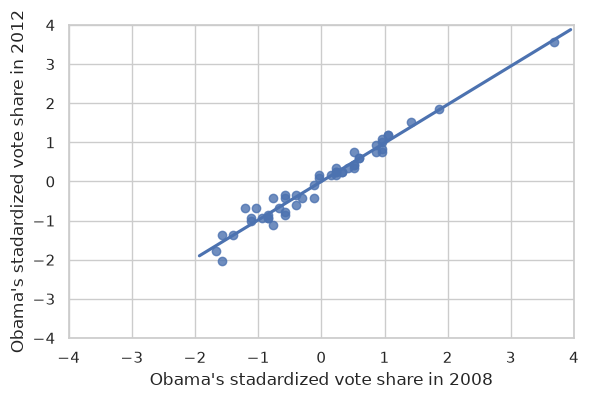

In [153]:
sns.lmplot(
    data=pres, x='Obama2008_z', y='Obama2012_z', ci=None, truncate=False,
    height=4, aspect=1.5,
).set(xlim=(-4,4), ylim=(-4,4),
      xlabel="Obama's stadardized vote share in 2008",
      ylabel="Obama's stadardized vote share in 2012").despine(right=False, top=False);

In [162]:
(pres['Obama2012_z'] > pres['Obama2008_z'])[
    (pres['Obama2008_z'] <= pres['Obama2008_z'].quantile(0.25))
].mean()

np.float64(0.5714285714285714)

In [164]:
(pres['Obama2012_z'] > pres['Obama2008_z'])[
    (pres['Obama2008_z'] >= pres['Obama2008_z'].quantile(0.75))
].mean()

np.float64(0.46153846153846156)

### 4.2.6 모형 적합도

In [165]:
florida = pd.read_csv('florida.csv')
florida.head()

,county,Clinton96,Dole96,Perot96,Bush00,Gore00,Buchanan00
0,Alachua,40144,25303,8072,34124,47365,263
1,Baker,2273,3684,667,5610,2392,73
2,Bay,17020,28290,5922,38637,18850,248
3,Bradford,3356,4038,819,5414,3075,65
4,Brevard,80416,87980,25249,115185,97318,570


In [166]:
fit2 = smf.ols('Buchanan00 ~ Perot96', data=florida).fit()

In [167]:
fit2.params

Intercept    1.345752
Perot96      0.035915
dtype: float64

In [169]:
TSS2 = ((florida['Buchanan00'] - florida['Buchanan00'].mean())**2).sum()
SSR2 = (fit2.resid**2).sum()
(TSS2 - SSR2)/ TSS2

np.float64(0.513033325505709)

In [170]:
def R2(fit):
    resid = fit.resid
    y = fit.fittedvalues + resid
    TSS = ((y - y.mean())**2).sum()
    SSR = (resid**2).sum()
    R2 = (TSS - SSR) / TSS
    return R2

R2(fit2)

np.float64(0.513033325505709)

In [171]:
fit2.rsquared

np.float64(0.5130333255057091)

In [172]:
fit1.rsquared

np.float64(0.9671579118703088)

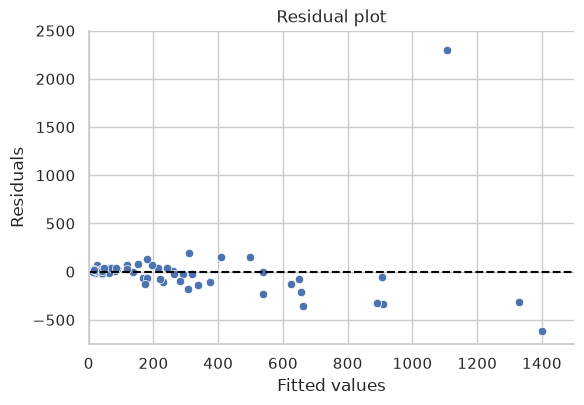

In [176]:
sns.relplot(
    x=fit2.fittedvalues, y=fit2.resid, height=4, aspect=1.5
).set(xlabel='Fitted values', ylabel='Residuals', title='Residual plot',
      xlim=(0,1500), ylim=(-750, 2500))

plt.axhline(y=0, color='black', linestyle='--');

In [177]:
florida['county'][fit2.resid == fit2.resid.max()]

49    PalmBeach
Name: county, dtype: str

In [178]:
florida_pb = florida.loc[florida.county != 'PalmBeach'].copy()

fit3 = smf.ols('Buchanan00 ~ Perot96', data=florida_pb).fit()
fit3.params

Intercept    45.841933
Perot96       0.024352
dtype: float64

In [179]:
fit3.rsquared

np.float64(0.8511674585300796)

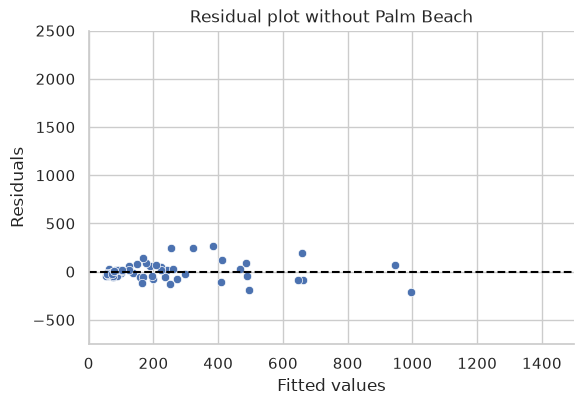

In [180]:
sns.relplot(
    x=fit3.fittedvalues, y=fit3.resid, height=4, aspect=1.5
).set(xlabel='Fitted values', ylabel='Residuals', title='Residual plot without Palm Beach',
      xlim=(0,1500), ylim=(-750, 2500))

plt.axhline(y=0, color='black', linestyle='--');

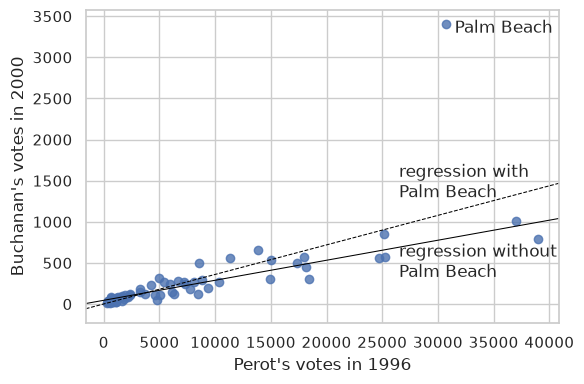

In [195]:
sns.lmplot(
    data=florida, x='Perot96', y='Buchanan00', ci=None, truncate=False,
    height=4, aspect=1.5,
    line_kws={'color':'black', 'linestyle':'--', 'linewidth':0.75}
).set(xlabel="Perot's votes in 1996", 
      ylabel="Buchanan's votes in 2000").despine(right=False, top=False)

xlim = plt.gca().get_xlim()

x_values = pd.DataFrame({'Perot96': xlim})
y_values = fit3.predict(x_values)

plt.plot(x_values, y_values, color='black', linewidth=.75)

plt.text(x=31500, y=3300, s='Palm Beach')
plt.text(x=26500, y=1300, s='regression with\nPalm Beach')
plt.text(x=26500, y=330, s='regression without\nPalm Beach');

---
## 4.3 회귀분석과 인과효과
---

### 4.3.1 무작위 실험

In [196]:
women = pd.read_csv('women.csv')
women.head()

,GP,village,reserved,female,irrigation,water
0,1,2,1,1,0,10
1,1,1,1,1,5,0
2,2,2,1,1,2,2
3,2,1,1,1,4,31
4,3,2,0,0,0,0


In [206]:
women['female'].loc[women.reserved == 1].mean()

np.float64(1.0)

In [207]:
women['female'].loc[women.reserved == 0].mean()

np.float64(0.07476635514018691)

In [209]:
women['water'][women.reserved == 1].mean() - women['water'][women.reserved == 0].mean()

np.float64(9.252422983731394)

In [210]:
women['irrigation'][women.reserved == 1].mean() - women['irrigation'][women.reserved == 0].mean()

np.float64(-0.369331948771201)

In [211]:
smf.ols('water ~ reserved', data=women).fit().params

Intercept    14.738318
reserved      9.252423
dtype: float64

In [212]:
smf.ols('irrigation ~ reserved', data=women).fit().params

Intercept    3.387850
reserved    -0.369332
dtype: float64

### 4.3.2: Regression with Multiple Predictors

In [213]:
social = pd.read_csv('social.csv')

In [214]:
cats = ['Control', 'Civic Duty', 'Hawthorne', 'Neighbors']
social['messages'] = (social['messages'].astype('category').cat.reorder_categories(cats))
social['messages'].cat.categories

Index(['Control', 'Civic Duty', 'Hawthorne', 'Neighbors'], dtype='str')

In [215]:
social['messages'].value_counts()

messages
Control       191243
Civic Duty     38218
Hawthorne      38204
Neighbors      38201
Name: count, dtype: int64

In [216]:
fit = smf.ols('primary2006 ~ messages', data=social).fit()
fit.params

Intercept                 0.296638
messages[T.Civic Duty]    0.017899
messages[T.Hawthorne]     0.025736
messages[T.Neighbors]     0.081310
dtype: float64

In [219]:
social['Civic_Duty'] = np.where(social['messages']=='Civic Duty', 1, 0)
social['Hawthorne'] = np.where(social['messages']=='Hawthorne', 1, 0)
social['Neighbors'] = np.where(social['messages']=='Neighbors', 1, 0)

In [221]:
dummies = (pd.get_dummies(social['messages'], drop_first=True, dtype='int').
           rename(columns={'Civic Duty':'Civic_Duty'}))

In [226]:
social[social.columns[-3:]].equals(dummies)

True

In [228]:
smf.ols('primary2006 ~ Civic_Duty + Hawthorne + Neighbors', data=social).fit().params

Intercept     0.296638
Civic_Duty    0.017899
Hawthorne     0.025736
Neighbors     0.081310
dtype: float64

In [230]:
unique_messages = pd.DataFrame({'messages': social['messages'].cat.categories})
unique_messages

,messages
0,Control
1,Civic Duty
2,Hawthorne
3,Neighbors


In [234]:
fit.predict(unique_messages)

0    0.296638
1    0.314538
2    0.322375
3    0.377948
dtype: float64

In [235]:
social.groupby('messages')['primary2006'].mean()

messages
Control       0.296638
Civic Duty    0.314538
Hawthorne     0.322375
Neighbors     0.377948
Name: primary2006, dtype: float64

In [237]:
fit_noint = smf.ols('primary2006 ~ -1 + messages', data=social).fit()
fit_noint.params

messages[Control]       0.296638
messages[Civic Duty]    0.314538
messages[Hawthorne]     0.322375
messages[Neighbors]     0.377948
dtype: float64

In [240]:
fit.params['messages[T.Neighbors]']

np.float64(0.08130991292051334)

In [243]:
(social.loc[social.messages == 'Neighbors', 'primary2006'].mean() - social.loc[social.messages == 'Control', 'primary2006'].mean()).round(7)

np.float64(0.0813099)

In [244]:
fit.rsquared_adj.round(7)

np.float64(0.0032728)

In [245]:
def adjR2(fit):
    resid = fit.resid # residuals
    y = fit.fittedvalues + resid # outcome variable
    n = len(y)
    p = len(fit.params)
    TSS_adj = ((y - y.mean())**2).sum() / (n - 1)
    SSR_adj = (resid**2).sum() / (n - p)
    R2_adj = 1 - SSR_adj / TSS_adj
    return R2_adj

adjR2(fit).round(7)

np.float64(0.0032728)

In [246]:
R2(fit).round(7)

np.float64(0.0032826)

### 4.3.3: Heterogeneous Treatment Effects

In [247]:
social_voter = social.loc[social.primary2004 == 1].copy()

In [249]:
ate_voter = (
    social_voter['primary2006'].loc[social_voter.messages == 'Neighbors'].mean()
    - social_voter['primary2006'].loc[social_voter.messages == 'Control'].mean()
)

ate_voter

np.float64(0.09652525355693264)

In [251]:
social_nonvoter = social.loc[social.primary2004 == 0].copy()


ate_nonvoter = (
    social_nonvoter['primary2006'].loc[social_nonvoter.messages == 'Neighbors'].mean()
    - social_nonvoter['primary2006'].loc[social_nonvoter.messages == 'Control'].mean()
)

ate_nonvoter

np.float64(0.0692961746200847)

In [252]:
ate_voter - ate_nonvoter

np.float64(0.02722907893684795)

In [260]:
social_neighbor = (
    social.loc[social['messages'].isin(['Control', 'Neighbors'])].copy()
)

social_neighbor['messages'] = social_neighbor['messages'].astype('object').astype('category')

fit_int = smf.ols(
    'primary2006 ~ primary2004 + messages + primary2004:messages', data=social_neighbor
).fit()

fit_int.params

Intercept                            0.237110
messages[T.Neighbors]                0.069296
primary2004                          0.148695
primary2004:messages[T.Neighbors]    0.027229
dtype: float64

In [261]:
social_neighbor['age'] = 2006 - social_neighbor.yearofbirth
social_neighbor['age'].describe().round(2)

count    229444.00
mean         49.82
std          14.46
min          20.00
25%          41.00
50%          50.00
75%          59.00
max         106.00
Name: age, dtype: float64

In [262]:
fit_age = smf.ols('primary2006 ~ age * messages', data=social_neighbor).fit()
fit_age.params

Intercept                    0.097473
messages[T.Neighbors]        0.049829
age                          0.003998
age:messages[T.Neighbors]    0.000628
dtype: float64

In [263]:
age_neighbor = pd.DataFrame({'age':np.arange(25, 86, 20), 
                             'messages': 'Neighbors'})
age_control = pd.DataFrame({'age': np.arange(25, 86, 20), 
                            'messages': 'Control'})

ate_age = fit_age.predict(age_neighbor) - fit_age.predict(age_control)
ate_age

0    0.065537
1    0.078103
2    0.090669
3    0.103236
dtype: float64

In [265]:
fit_age2 = smf.ols('primary2006 ~ age + I(age**2) + messages + age:messages + ' + 'I(age**2):messages', data=social_neighbor).fit()
fit_age2.params

Intercept                           -0.073846
messages[T.Neighbors]               -0.043302
age                                  0.011427
age:messages[T.Neighbors]            0.004646
I(age ** 2)                         -0.000074
I(age ** 2):messages[T.Neighbors]   -0.000040
dtype: float64

In [266]:
yT_hat = fit_age2.predict(pd.DataFrame({'age':np.arange(25,86),
                                        'messages':'Neighbors'}))
yC_hat = fit_age2.predict(pd.DataFrame({'age':np.arange(25,86),
                                        'messages':'Control'}))

ate_age2 = yT_hat - yC_hat
ate_age2.head()

0    0.048091
1    0.050717
2    0.053264
3    0.055731
4    0.058120
dtype: float64

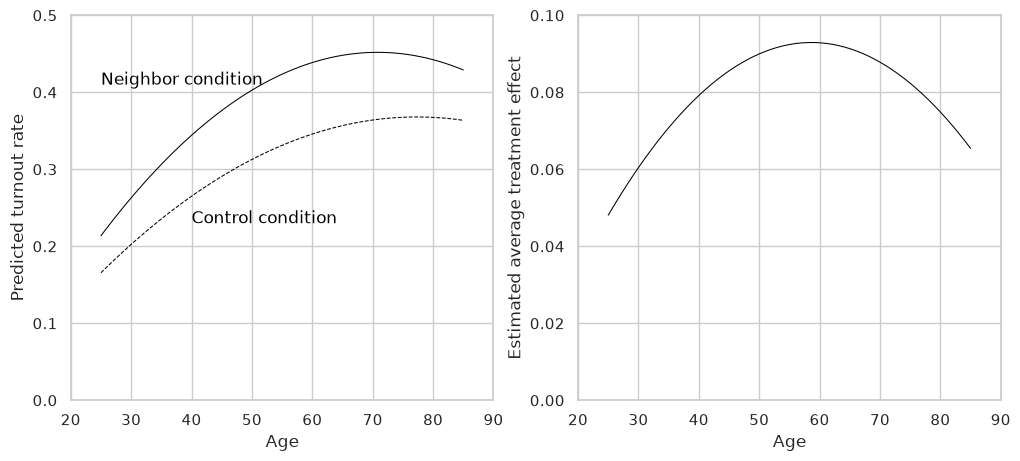

In [270]:
fig, axs = plt.subplots(1,2,figsize=(12,5))

sns.lineplot(
    x=np.arange(25,86), y=yT_hat, color='black', linewidth=.75, ax=axs[0]
).set(xlabel='Age', ylabel='Predicted turnout rate',
      xlim=(20,90), ylim=(0, .5))

sns.lineplot(
    x=np.arange(25,86), y=yC_hat, color='black', linestyle='--', linewidth=.75, ax=axs[0]
)

axs[0].text(x=25, y=.41, s='Neighbor condition', color='black')
axs[0].text(x=40, y=.23, s='Control condition', color='black')

sns.lineplot(
    x=np.arange(25,86), y=ate_age2, color='black', linewidth=.75, ax=axs[1]
).set(xlabel='Age', ylabel='Estimated average treatment effect',
      xlim=(20,90), ylim=(0, .1));

### 4.3.4: Regression Discontinuity Design

In [271]:
MPs = pd.read_csv('MPs.csv')
MPs.columns

Index(['surname', 'firstname', 'party', 'ln.gross', 'ln.net', 'yob', 'yod',
       'margin.pre', 'region', 'margin'],
      dtype='str')

In [272]:
MPs.columns = MPs.columns.str.replace('.', '_')
MPs.columns

Index(['surname', 'firstname', 'party', 'ln_gross', 'ln_net', 'yob', 'yod',
       'margin_pre', 'region', 'margin'],
      dtype='str')

In [273]:
MPs_labour = MPs.loc[MPs['party']=='labour'].copy()
MPs_tory = MPs.loc[MPs['party']=='tory'].copy()

labour_fit1 = smf.ols('ln_net ~ margin',
                      data=MPs_labour[MPs_labour.margin < 0]).fit()
labour_fit2 = smf.ols('ln_net ~ margin',
                      data=MPs_labour[MPs_labour.margin > 0]).fit()

tory_fit1 = smf.ols('ln_net ~ margin',
                      data=MPs_tory[MPs_tory.margin < 0]).fit()
tory_fit2 = smf.ols('ln_net ~ margin',
                      data=MPs_tory[MPs_tory.margin > 0]).fit()

In [287]:
# Labour: range of predictions
y1l_range = np.array([MPs_labour['margin'].min(), 0])
y2l_range = np.array([0, MPs_labour['margin'].max()])

# prediction: Labor
y1_labour = labour_fit1.predict(pd.DataFrame({'margin': y1l_range}))
y2_labour = labour_fit2.predict(pd.DataFrame({'margin': y2l_range}))

# Tory: range of predictions
y1t_range = np.array([MPs_tory['margin'].min(), 0])
y2t_range = np.array([0, MPs_tory['margin'].max()])

# prediction: Tory
y1_tory = tory_fit1.predict(pd.DataFrame({'margin': y1t_range}))
y2_tory = tory_fit2.predict(pd.DataFrame({'margin': y2t_range}))

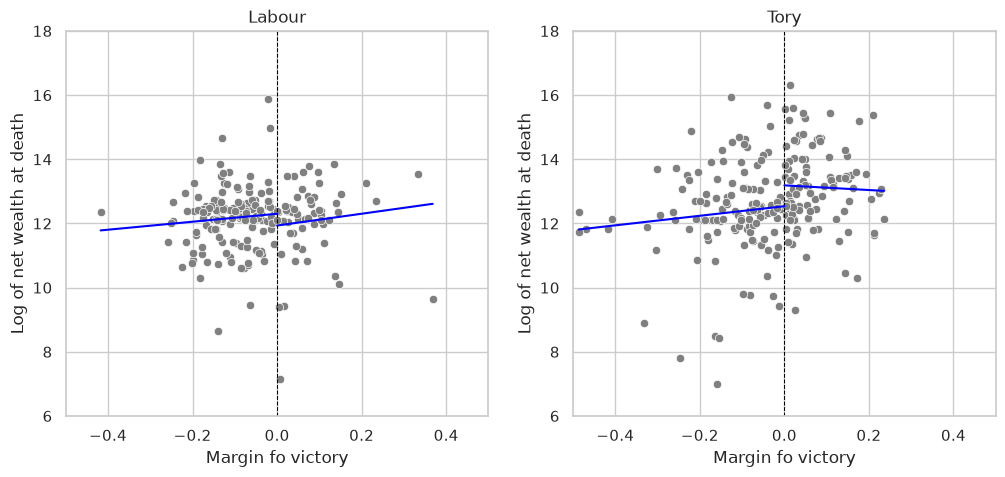

In [290]:
fig, axs = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(
    data=MPs_labour, x='margin', y='ln_net', color='gray', ax=axs[0]
).set(xlim=(-0.5, 0.5), ylim=(6, 18), xlabel='Margin fo victory',
      ylabel='Log of net wealth at death', title='Labour')

axs[0].axvline(x=0, color='black', linestyle='--', linewidth=.75)
axs[0].plot(y1l_range, y1_labour, color='blue')
axs[0].plot(y2l_range, y2_labour, color='blue')


sns.scatterplot(
    data=MPs_tory, x='margin', y='ln_net', color='gray', ax=axs[1]
).set(xlim=(-0.5, 0.5), ylim=(6, 18), xlabel='Margin fo victory',
      ylabel='Log of net wealth at death', title='Tory')

axs[1].axvline(x=0, color='black', linestyle='--', linewidth=.75)
axs[1].plot(y1t_range, y1_tory, color='blue')
axs[1].plot(y2t_range, y2_tory, color='blue')

In [294]:
tory_MP = np.exp(y2_tory[0])
tory_MP 

np.float64(533813.4685368622)

In [295]:
tory_nonMP = np.exp(y1_tory[1])
tory_nonMP.round(2)

np.float64(278762.55)

In [296]:
tory_MP - tory_nonMP

np.float64(255050.92314682307)

In [297]:
tory_fit3 = smf.ols('margin_pre ~ margin', 
                    data=MPs_tory[MPs_tory.margin < 0]).fit()

tory_fit4 = smf.ols('margin_pre ~ margin',
                    data=MPs_tory[MPs_tory.margin > 0]).fit()

# the difference between the two incercepts is the estimated effect
tory_fit4.params['Intercept'] - tory_fit3.params['Intercept']

np.float64(-0.017255775697591354)

---
## 4.5 연습문제
---